# NB03b: Support Network Enrichment with InterProScan Annotations

Re-run the H1 enrichment analysis using InterProScan GO terms (68% coverage)
instead of old FB SEED annotations (variable coverage). This should provide
much better power to detect functional enrichment in AMR support networks.

**Approach:**
1. Map FB genes → gene_cluster_id → InterProScan GO terms
2. Use GO biological process terms for functional categorization
3. Re-run Fisher enrichment and permutation tests

**Inputs:** `data/amr_cofitness_partners.csv`, `data/fb_interproscan_go.csv`, `data/fb_interproscan_pfam.csv`

In [1]:
import os
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore', category=FutureWarning)

_here = os.path.abspath('')
if os.path.basename(_here) == 'notebooks':
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))
elif os.path.exists(os.path.join(_here, 'projects', 'amr_cofitness_networks')):
    REPO = _here
else:
    REPO = os.path.abspath(os.path.join(_here, '..', '..', '..'))

PROJECT = os.path.join(REPO, 'projects', 'amr_cofitness_networks')
DATA = os.path.join(PROJECT, 'data')
FIGURES = os.path.join(PROJECT, 'figures')
CVF_DATA = os.path.join(REPO, 'projects', 'conservation_vs_fitness', 'data')
AMR_DATA = os.path.join(REPO, 'projects', 'amr_fitness_cost', 'data')

# Load cofitness partners
partners = pd.read_csv(os.path.join(DATA, 'amr_cofitness_partners.csv'))
partners['amr_locusId'] = partners['amr_locusId'].astype(str)
partners['partner_locusId'] = partners['partner_locusId'].astype(str)
extra = partners[~partners['is_near_operon']].copy()

# Load FB-pangenome link for locusId → gene_cluster_id mapping
fb_link = pd.read_csv(os.path.join(CVF_DATA, 'fb_pangenome_link.tsv'), sep='\t')
fb_link['locusId'] = fb_link['locusId'].astype(str)
locus_to_cluster = dict(zip(
    zip(fb_link['orgId'], fb_link['locusId']),
    fb_link['gene_cluster_id']
))

# Load InterProScan GO
go_annot = pd.read_csv(os.path.join(DATA, 'fb_interproscan_go.csv'))
# Load Pfam
pfam_annot = pd.read_csv(os.path.join(DATA, 'fb_interproscan_pfam.csv'))

print(f'Extra-operon partners: {len(extra):,}')
print(f'GO annotations: {len(go_annot):,} ({go_annot["gene_cluster_id"].nunique():,} clusters)')
print(f'Pfam annotations: {len(pfam_annot):,} ({pfam_annot["gene_cluster_id"].nunique():,} clusters)')

Extra-operon partners: 179,375
GO annotations: 438,000 (111,253 clusters)
Pfam annotations: 228,672 (143,794 clusters)


## 1. Map partner genes to GO terms via gene_cluster_id

In [2]:
# Map partner locusIds to gene_cluster_ids
extra['partner_cluster_id'] = extra.apply(
    lambda r: locus_to_cluster.get((r['orgId'], r['partner_locusId'])), axis=1)

print(f'Partners mapped to gene clusters: {extra["partner_cluster_id"].notna().sum():,} / {len(extra):,} '
      f'({extra["partner_cluster_id"].notna().mean()*100:.1f}%)')

# Build GO lookup: gene_cluster_id → set of GO terms
cluster_go = go_annot.groupby('gene_cluster_id')['go_id'].apply(set).to_dict()

# Map GO terms onto partners
extra['partner_go_terms'] = extra['partner_cluster_id'].map(
    lambda cid: cluster_go.get(cid, set()) if pd.notna(cid) else set())

has_go = extra['partner_go_terms'].apply(len) > 0
print(f'Partners with GO annotations: {has_go.sum():,} / {len(extra):,} ({has_go.mean()*100:.1f}%)')

# Build Pfam lookup similarly
cluster_pfam = pfam_annot.groupby('gene_cluster_id')['signature_acc'].apply(set).to_dict()
extra['partner_pfam'] = extra['partner_cluster_id'].map(
    lambda cid: cluster_pfam.get(cid, set()) if pd.notna(cid) else set())

has_pfam = extra['partner_pfam'].apply(len) > 0
print(f'Partners with Pfam annotations: {has_pfam.sum():,} / {len(extra):,} ({has_pfam.mean()*100:.1f}%)')

Partners mapped to gene clusters: 171,051 / 179,375 (95.4%)


Partners with GO annotations: 107,909 / 179,375 (60.2%)


Partners with Pfam annotations: 146,757 / 179,375 (81.8%)


## 2. GO term enrichment in AMR support networks

For each organism: which GO terms are overrepresented in AMR cofitness partners
vs all genes in that organism?

In [3]:
# Build per-organism GO backgrounds
# For each organism, get GO terms for all genes (not just AMR partners)
all_locus_clusters = {}
for org in extra['orgId'].unique():
    org_link = fb_link[fb_link['orgId'] == org]
    all_locus_clusters[org] = dict(zip(org_link['locusId'].astype(str), org_link['gene_cluster_id']))

# Per-organism GO enrichment using Fisher's exact test
go_enrichment = []

for org in sorted(extra['orgId'].unique()):
    # All genes in this organism with GO annotations
    org_clusters = all_locus_clusters.get(org, {})
    bg_go_counts = Counter()
    n_bg_annotated = 0
    for cid in org_clusters.values():
        terms = cluster_go.get(cid, set())
        if terms:
            n_bg_annotated += 1
            for t in terms:
                bg_go_counts[t] += 1
    
    if n_bg_annotated < 100:
        continue
    
    # AMR support network genes with GO annotations
    org_partners = extra[extra['orgId'] == org]
    support_clusters = set(org_partners['partner_cluster_id'].dropna())
    sup_go_counts = Counter()
    n_sup_annotated = 0
    for cid in support_clusters:
        terms = cluster_go.get(cid, set())
        if terms:
            n_sup_annotated += 1
            for t in terms:
                sup_go_counts[t] += 1
    
    if n_sup_annotated < 10:
        continue
    
    # Test each GO term present in >=5 support genes
    for go_term in sup_go_counts:
        if sup_go_counts[go_term] < 5:
            continue
        
        # 2x2 table: support vs background, has_term vs not
        a = sup_go_counts[go_term]  # support with term
        b = n_sup_annotated - a      # support without term
        c = bg_go_counts[go_term]    # background with term
        d = n_bg_annotated - c       # background without term
        
        odds, p = stats.fisher_exact([[a, b], [c, d]], alternative='greater')
        
        go_enrichment.append({
            'orgId': org,
            'go_term': go_term,
            'support_count': a,
            'support_total': n_sup_annotated,
            'support_pct': a / n_sup_annotated * 100,
            'bg_count': c,
            'bg_total': n_bg_annotated,
            'bg_pct': c / n_bg_annotated * 100,
            'odds_ratio': odds,
            'p_value': p,
        })

go_enrich_df = pd.DataFrame(go_enrichment)
print(f'GO enrichment tests: {len(go_enrich_df):,}')

# BH-FDR within each organism
go_enrich_df['q_value'] = np.nan
for org in go_enrich_df['orgId'].unique():
    mask = go_enrich_df['orgId'] == org
    if mask.sum() > 0:
        _, q, _, _ = multipletests(go_enrich_df.loc[mask, 'p_value'], method='fdr_bh')
        go_enrich_df.loc[mask, 'q_value'] = q

go_enrich_df['significant'] = go_enrich_df['q_value'] < 0.05

print(f'Significant (q<0.05): {go_enrich_df["significant"].sum():,}')
print(f'Organisms tested: {go_enrich_df["orgId"].nunique()}')

GO enrichment tests: 3,193
Significant (q<0.05): 35
Organisms tested: 28


In [4]:
# Which GO terms are most consistently enriched across organisms?
sig = go_enrich_df[go_enrich_df['significant']]
n_orgs = go_enrich_df['orgId'].nunique()

go_consistency = sig.groupby('go_term').agg(
    n_orgs_sig=('orgId', 'nunique'),
    mean_odds=('odds_ratio', 'mean'),
    mean_support_pct=('support_pct', 'mean'),
    mean_bg_pct=('bg_pct', 'mean'),
).sort_values('n_orgs_sig', ascending=False)

print(f'GO terms significant in at least 1 organism: {len(go_consistency)}')
print(f'GO terms significant in >=3 organisms:')
multi_org = go_consistency[go_consistency['n_orgs_sig'] >= 3]
print(f'  {len(multi_org)} GO terms')
print()

# Show top 30 with descriptions where available
print(f'{"GO term":15s} {"Orgs":>5s} {"MeanOR":>7s} {"Sup%":>6s} {"Bg%":>6s}')
print('-' * 45)
for go_term, row in go_consistency.head(30).iterrows():
    print(f'{go_term:15s} {row["n_orgs_sig"]:5.0f} {row["mean_odds"]:7.2f} '
          f'{row["mean_support_pct"]:6.1f} {row["mean_bg_pct"]:6.1f}')

GO terms significant in at least 1 organism: 15
GO terms significant in >=3 organisms:
  6 GO terms

GO term          Orgs  MeanOR   Sup%    Bg%
---------------------------------------------
GO:0071973          5    4.69    3.0    0.7
GO:0044780          5    5.30    1.8    0.3
GO:0009288          4    4.87    2.2    0.5
GO:0071978          4    4.97    2.0    0.4
GO:0000105          3    5.31    1.5    0.3
GO:0000162          3    5.30    1.3    0.2
GO:0000160          2    1.72    6.2    3.7
GO:0007165          2    1.78    5.8    3.4
GO:0006935          1    3.12    3.4    1.1
GO:0000155          1    2.13    4.4    2.1
GO:0003774          1    5.98    1.7    0.3
GO:0016310          1    2.22    4.8    2.2
GO:0016020          1    1.42   24.1   18.3
GO:0015074          1    4.43    3.1    0.7
GO:0016772          1    2.10    4.7    2.3


In [5]:
# Enrichment by AMR mechanism: do different mechanisms enrich different GO terms?
mech_go_enrichment = []

for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance']:
    mech_extra = extra[extra['amr_mechanism'] == mech]
    
    for org in sorted(mech_extra['orgId'].unique()):
        org_clusters = all_locus_clusters.get(org, {})
        bg_go_counts = Counter()
        n_bg = 0
        for cid in org_clusters.values():
            terms = cluster_go.get(cid, set())
            if terms:
                n_bg += 1
                for t in terms:
                    bg_go_counts[t] += 1
        
        if n_bg < 100:
            continue
        
        # Mechanism-specific support network
        org_mech = mech_extra[mech_extra['orgId'] == org]
        sup_clusters = set(org_mech['partner_cluster_id'].dropna())
        sup_go = Counter()
        n_sup = 0
        for cid in sup_clusters:
            terms = cluster_go.get(cid, set())
            if terms:
                n_sup += 1
                for t in terms:
                    sup_go[t] += 1
        
        if n_sup < 10:
            continue
        
        for go_term in sup_go:
            if sup_go[go_term] < 3:
                continue
            a = sup_go[go_term]
            b = n_sup - a
            c = bg_go_counts.get(go_term, 0)
            d = n_bg - c
            odds, p = stats.fisher_exact([[a, b], [c, d]], alternative='greater')
            
            mech_go_enrichment.append({
                'mechanism': mech,
                'orgId': org,
                'go_term': go_term,
                'odds_ratio': odds,
                'p_value': p,
            })

mech_go_df = pd.DataFrame(mech_go_enrichment)
# FDR per mechanism-organism
mech_go_df['q_value'] = np.nan
for key, grp in mech_go_df.groupby(['mechanism', 'orgId']):
    if len(grp) > 0:
        _, q, _, _ = multipletests(grp['p_value'], method='fdr_bh')
        mech_go_df.loc[grp.index, 'q_value'] = q

mech_go_df['significant'] = mech_go_df['q_value'] < 0.05

print(f'Mechanism-specific GO enrichment tests: {len(mech_go_df):,}')
print(f'Significant: {mech_go_df["significant"].sum():,}')
print()

for mech in ['efflux', 'enzymatic_inactivation', 'metal_resistance']:
    sub = mech_go_df[mech_go_df['mechanism'] == mech]
    sig_sub = sub[sub['significant']]
    n_orgs = sub['orgId'].nunique()
    print(f'{mech:30s}: {len(sig_sub)} sig tests across {sig_sub["orgId"].nunique()}/{n_orgs} orgs')
    if len(sig_sub) > 0:
        top_go = sig_sub.groupby('go_term').size().sort_values(ascending=False).head(5)
        for go, cnt in top_go.items():
            print(f'    {go}: sig in {cnt} organisms')

Mechanism-specific GO enrichment tests: 9,244
Significant: 212

efflux                        : 72 sig tests across 12/28 orgs
    GO:0000105: sig in 6 organisms
    GO:0000162: sig in 5 organisms
    GO:0071973: sig in 5 organisms
    GO:0044780: sig in 4 organisms
    GO:0009288: sig in 3 organisms
enzymatic_inactivation        : 55 sig tests across 8/26 orgs
    GO:0000162: sig in 4 organisms
    GO:0071973: sig in 3 organisms
    GO:0009288: sig in 3 organisms
    GO:0044780: sig in 3 organisms
    GO:0006935: sig in 2 organisms
metal_resistance              : 85 sig tests across 9/22 orgs
    GO:0071973: sig in 6 organisms
    GO:0009288: sig in 5 organisms
    GO:0071978: sig in 5 organisms
    GO:0006935: sig in 4 organisms
    GO:0044780: sig in 4 organisms


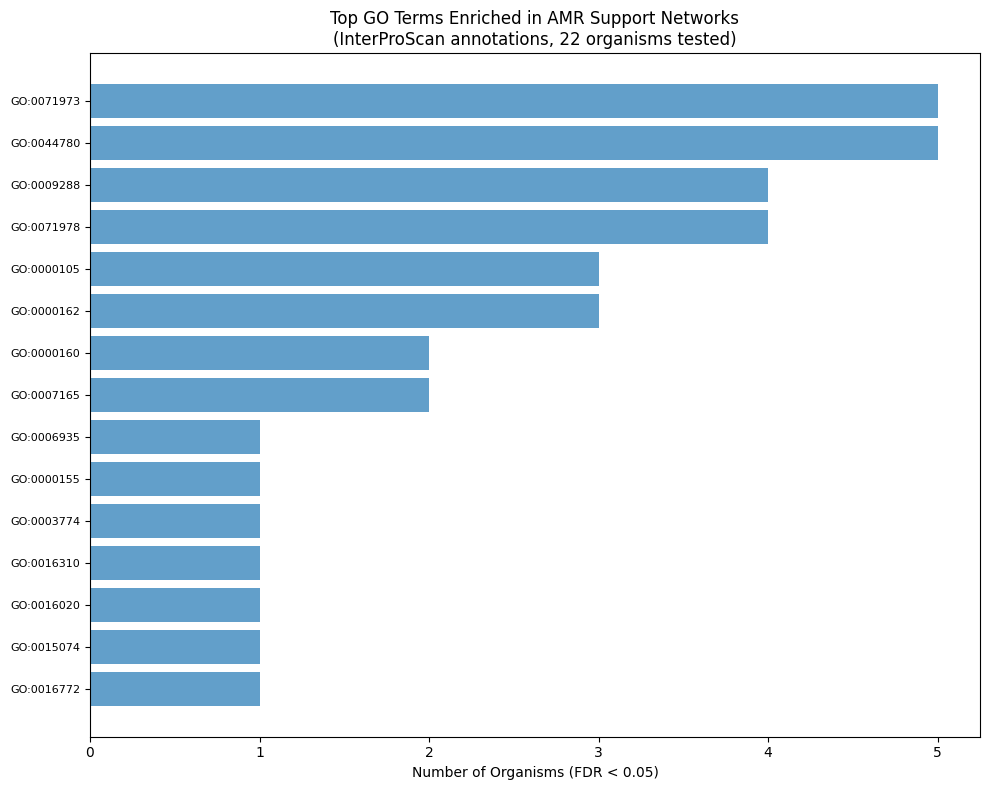

Saved to figures/go_enrichment_interproscan.png


In [6]:
# Summary figure: top GO terms enriched in AMR support networks
if len(go_consistency) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))
    
    top_go = go_consistency.head(20)
    y_pos = range(len(top_go))
    
    ax.barh(y_pos, top_go['n_orgs_sig'], color='tab:blue', alpha=0.7)
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top_go.index, fontsize=8)
    ax.set_xlabel('Number of Organisms (FDR < 0.05)')
    ax.set_title(f'Top GO Terms Enriched in AMR Support Networks\n'
                 f'(InterProScan annotations, {n_orgs} organisms tested)')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES, 'go_enrichment_interproscan.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to figures/go_enrichment_interproscan.png')
else:
    print('No significant GO enrichments to plot')

In [7]:
# Save results
go_enrich_df.to_csv(os.path.join(DATA, 'go_enrichment_interproscan.csv'), index=False)
mech_go_df.to_csv(os.path.join(DATA, 'mechanism_go_enrichment.csv'), index=False)

print(f'=== NB03b Summary ===')
print(f'Annotation source: InterProScan GO (68% cluster coverage vs ~15% old SEED)')
print(f'GO enrichment tests: {len(go_enrich_df):,}')
print(f'Significant (FDR<0.05): {go_enrich_df["significant"].sum():,}')
print(f'GO terms sig in >=3 organisms: {len(multi_org)}')
if len(go_consistency) > 0:
    print(f'Top enriched GO term: {go_consistency.index[0]} ({go_consistency.iloc[0]["n_orgs_sig"]:.0f} organisms)')

=== NB03b Summary ===
Annotation source: InterProScan GO (68% cluster coverage vs ~15% old SEED)
GO enrichment tests: 3,193
Significant (FDR<0.05): 35
GO terms sig in >=3 organisms: 6
Top enriched GO term: GO:0071973 (5 organisms)
